# Deterministic SVG coverage inspection

This notebook audits one selected generator visually. It creates deterministic branch and boundary cases, prioritizes manually specified cases, and renders all cases into one vector contact sheet. It does not rasterize, calculate OBBs, format labels, or write files.

In [17]:
from copy import deepcopy
from pathlib import Path
import sys
from xml.etree.ElementTree import Element, SubElement, fromstring, register_namespace, tostring

import numpy as np
from IPython.display import SVG, display

PROJECT_ROOT = next(
    (candidate for candidate in [Path.cwd(), *Path.cwd().parents]
     if (candidate / '06_configs' / 'ontology.yaml').exists()),
    Path.cwd(),
)
SCRIPTS_ROOT = PROJECT_ROOT / '01_scripts'
if str(SCRIPTS_ROOT) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_ROOT))

from generation.core.models import GenerationConfig
from generation.core.sampling import load_sampling_config
from generation.registry import COMPOSITE_GENERATORS, GENERATOR_REGISTRY

sampling_config = load_sampling_config(
    ontology_path=PROJECT_ROOT / '06_configs' / 'ontology.yaml',
    sampling_path=PROJECT_ROOT / '06_configs' / 'symbol_sampling.yaml',
)
SVG_NS = 'http://www.w3.org/2000/svg'
register_namespace('', SVG_NS)


## Inspection configuration

Manual cases are the primary iteration layer. Automatic cases can be disabled when a focused hand-authored set is preferred.

In [18]:
class_key = ('instructive', 'jb')
MANUAL_CASES = [
    # {
    #     'id': 'dc_upper_tilted',
    #     'overrides': {
    #         'bar_stem_ratio': 0.333,
    #         'cross_bar_ratio': 0.36,
    #         'cross_bar_y': 0.62,
    #         'cross_bar_angle_deg': 15.0,
    #     },
    # },
]
INCLUDE_AUTOMATIC_CASES = True
COLUMNS = 4
TILE_WIDTH = 180
TILE_HEIGHT = 180
GENERATION_CONFIG = GenerationConfig(
    canvas_width_px=150,
    canvas_height_px=150,
    target_visible_px=90,
    rotation_deg=0.0,
    stroke_width_normalized=4.0,
)

## Case-generation tooling

These helpers inspect declarations only. They do not sample or invoke SVG generators. Derived parameters are intentionally omitted because the sampler computes them from each effective case.

In [19]:
def _parameter_distribution(parameter):
    distribution = parameter.get('distribution')
    if distribution is None and parameter.get('kind') == 'derived':
        return {'type': 'derived'}
    return distribution


def _distribution_cases(parameter_name, distribution, base_overrides=None, label_prefix=''):
    base_overrides = dict(base_overrides or {})
    if distribution is None or distribution.get('type') == 'derived':
        return []

    dtype = distribution['type']
    if dtype == 'fixed':
        return [{
            'overrides': {**base_overrides, parameter_name: distribution['value']},
            'parameter': parameter_name,
            'label': f'{label_prefix}{parameter_name}={distribution["value"]!r}',
        }]

    if dtype == 'categorical':
        return [
            {
                'overrides': {**base_overrides, parameter_name: value},
                'parameter': parameter_name,
                'label': f'{label_prefix}{parameter_name}={value!r}',
            }
            for value, probability in distribution['probabilities'].items()
            if float(probability) > 0
        ]

    if dtype == 'truncated_normal':
        return [
            {
                'overrides': {**base_overrides, parameter_name: value},
                'parameter': parameter_name,
                'label': f'{label_prefix}{parameter_name}={point} ({value:g})',
            }
            for point, value in (
                ('min', float(distribution['min'])),
                ('mean', float(distribution['mean'])),
                ('max', float(distribution['max'])),
            )
        ]

    if dtype == 'mixture':
        cases = []
        for index, component in enumerate(distribution['components']):
            cases.extend(_distribution_cases(
                parameter_name,
                component['distribution'],
                base_overrides,
                f'{label_prefix}{parameter_name}[component {index}] ',
            ))
        return cases

    if dtype == 'conditional':
        dependency = distribution['depends_on'][0]
        cases = []
        for dependency_value, branch in distribution['cases'].items():
            branch_overrides = {**base_overrides, dependency: dependency_value}
            cases.extend(_distribution_cases(
                parameter_name, branch, branch_overrides,
                f'{label_prefix}{dependency}={dependency_value!r}; '
            ))
        return cases

    raise ValueError(f'Unsupported automatic case distribution: {dtype!r}')


def distribution_cases(spec):
    cases = []
    for name, parameter in spec.raw.get('parameters', {}).items():
        distribution = _parameter_distribution(parameter)
        cases.extend(_distribution_cases(name, distribution))
    return cases


def conditional_cases(spec):
    return [case for case in distribution_cases(spec) if '; ' in case['label']]


def mixture_cases(spec):
    return [case for case in distribution_cases(spec) if 'component ' in case['label']]


def automatic_cases(spec):
    cases = distribution_cases(spec)
    for variant_name, variant in spec.variants.items():
        variant_overrides = {'variant': variant_name}
        for name, parameter in variant.get('parameters', {}).items():
            cases.extend(_distribution_cases(
                name, _parameter_distribution(parameter), variant_overrides,
                f'variant={variant_name!r}; '
            ))
    return cases


def merge_cases(manual_cases, generated_cases):
    merged = []
    seen_ids = set()
    for case in manual_cases:
        case = dict(case)
        case.setdefault('label', case['id'])
        case.setdefault('parameter', 'manual')
        case['seed'] = 1000 + len(merged)
        merged.append(case)
        seen_ids.add(case['id'])
    for index, case in enumerate(generated_cases):
        case = dict(case)
        case['id'] = f'auto_{index:03d}_{case["parameter"]}'
        if case['id'] in seen_ids:
            continue
        case['seed'] = 2000 + index
        merged.append(case)
        seen_ids.add(case['id'])
    return merged


def make_contact_sheet(rendered_cases, columns=COLUMNS, tile_width=TILE_WIDTH, tile_height=TILE_HEIGHT):
    rows = max(1, (len(rendered_cases) + columns - 1) // columns)
    sheet = Element(f'{{{SVG_NS}}}svg', {
        'width': str(columns * tile_width),
        'height': str(rows * tile_height),
        'viewBox': f'0 0 {columns * tile_width} {rows * tile_height}',
    })
    for index, item in enumerate(rendered_cases):
        column, row = index % columns, index // columns
        x, y = column * tile_width, row * tile_height
        tile = SubElement(sheet, 'g', {'transform': f'translate({x} {y})'})
        SubElement(tile, 'rect', {
            'x': '1', 'y': '1', 'width': str(tile_width - 2),
            'height': str(tile_height - 2), 'fill': 'white',
            'stroke': '#cccccc',
        })
        SubElement(tile, 'text', {
            'x': '8', 'y': '16', 'font-family': 'sans-serif',
            'font-size': '11', 'fill': 'black',
        }).text = item['case']['id']
        child = fromstring(item['generated'].svg)
        child.set('x', '0')
        child.set('y', '22')
        child.set('width', str(tile_width))
        child.set('height', str(tile_height - 24))
        tile.append(deepcopy(child))
    return tostring(sheet, encoding='unicode')

## Case preparation

This cell resolves the selected class and prepares the ordered case list. It does not invoke any SVG generator.

In [20]:
if class_key not in GENERATOR_REGISTRY:
    raise KeyError(f'{class_key!r} is not an active SVG generator: {list(GENERATOR_REGISTRY)}')
spec = sampling_config.resolve(*class_key)
prepared_cases = merge_cases(
    MANUAL_CASES,
    automatic_cases(spec) if INCLUDE_AUTOMATIC_CASES else [],
)

print(f'{class_key[0]}.{class_key[1]}: {len(prepared_cases)} cases')
for case in prepared_cases:
    print(f"{case['id']}: {case.get('label', '')} | {case['overrides']}")

instructive.jb: 10 cases
auto_000_phenotype: phenotype='canonical' | {'phenotype': 'canonical'}
auto_001_max_width_ratio: max_width_ratio=min (0.075) | {'max_width_ratio': 0.075}
auto_002_max_width_ratio: max_width_ratio=mean (0.1) | {'max_width_ratio': 0.1}
auto_003_max_width_ratio: max_width_ratio=max (0.15) | {'max_width_ratio': 0.15}
auto_004_taper_extent: taper_extent=min (0.55) | {'taper_extent': 0.55}
auto_005_taper_extent: taper_extent=mean (0.72) | {'taper_extent': 0.72}
auto_006_taper_extent: taper_extent=max (0.9) | {'taper_extent': 0.9}
auto_007_stroke_width: stroke_width=min (1.4) | {'stroke_width': 1.4}
auto_008_stroke_width: stroke_width=mean (1.8) | {'stroke_width': 1.8}
auto_009_stroke_width: stroke_width=max (2.2) | {'stroke_width': 2.2}


## Execute sampling and SVG generation

This is the only cell that invokes registry generators. Registered composite generators realize one reusable prototype per component role before SVG generation. All generated SVGs are combined into one vector contact sheet.

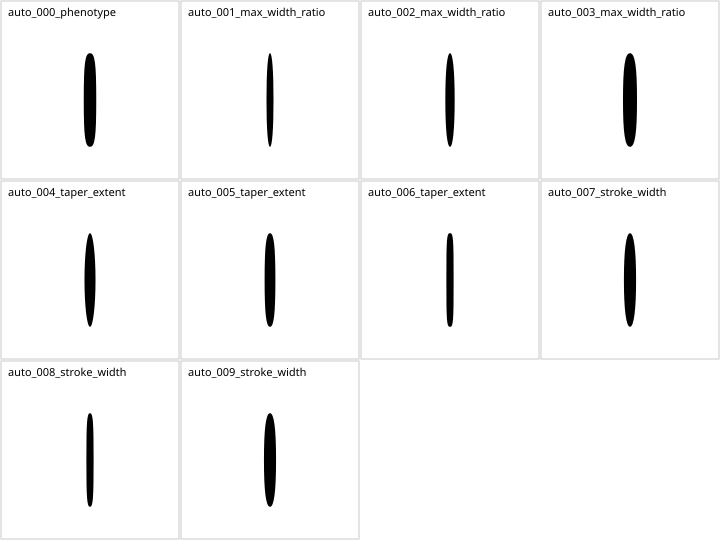


=== auto_000_phenotype ===
Overrides: {'phenotype': 'canonical'}
Sampled: {'phenotype': 'canonical', 'max_width_ratio': 0.13359064384736738, 'taper_extent': 0.7893710226398254, 'stroke_width': 1.7732484996065523}
Derived: {}
Metadata: {'class_id': 15, 'class_name': 'jb', 'phenotype': 'canonical', 'max_width_ratio': 0.13359064384736738, 'taper_extent': 0.7893710226398254, 'height_px': 90.0, 'max_width_px': 12.023157946263064, 'center_px': [75.0, 75.0], 'top_tip_px': [75.0, 30.0], 'bottom_tip_px': [75.0, 120.0], 'center_extrema_px': [[68.98842102686847, 75.0], [81.01157897313153, 75.0]], 'path_segments': [{'control_1_px': [79.7453662417009, 30.0], 'control_2_px': [81.01157897313153, 39.47830398120786], 'end_px': [81.01157897313153, 75.0]}, {'control_1_px': [81.01157897313153, 110.52169601879214], 'control_2_px': [79.7453662417009, 120.0], 'end_px': [75.0, 120.0]}, {'control_1_px': [70.2546337582991, 120.0], 'control_2_px': [68.98842102686847, 110.52169601879214], 'end_px': [68.988421026

In [21]:
generator = GENERATOR_REGISTRY[class_key]
rendered_cases = []
for case in prepared_cases:
    rng = np.random.default_rng(case['seed'])
    sample = sampling_config.sample(
        *class_key,
        rng,
        seed=case['seed'],
        overrides=case['overrides'],
    )
    composite = (
        sampling_config.realize_components(*class_key, sample, rng)
        if class_key in COMPOSITE_GENERATORS
        else None
    )
    generator_input = composite if composite is not None else sample
    generated = generator(spec, generator_input, GENERATION_CONFIG)
    rendered_cases.append({
        'case': case, 'generated': generated, 'sample': sample,
        'composite': composite,
    })

display(SVG(data=make_contact_sheet(rendered_cases)))

for item in rendered_cases:
    case = item['case']
    sample = item['sample']
    print(f"\n=== {case['id']} ===")
    print('Overrides:', case['overrides'])
    print('Sampled:', sample.parameters)
    print('Derived:', sample.derived)
    if item['composite'] is not None:
        print('Component prototypes:', {
            role: prototype.sample.as_dict()
            for role, prototype in item['composite'].prototypes.items()
        })
    print('Metadata:', item['generated'].metadata)